<h1 style="font-size: 2.8rem; font-weight: 700; color: #1a1a2e; border-bottom: 3px solid #4a90e2; padding-bottom: 0.3rem;">Analysis of U.S. Domestic Flight Delay Causes (2003-2025)</h1>


<h2 style="font-size: 2.2rem; font-weight: 650; color: #16213e; border-bottom: 1px solid #ccc; padding-bottom: 0.2rem;">1.1 Tool Setup and Data Loading</h2>

Before starting the analysis, we import the necessary Python libraries: `pandas` for data handling, `numpy` for calculations, and `matplotlib` and `seaborn` for charting. We set a consistent chart style and size to ensure all visualizations are clear and uniform.

The data comes from the U.S. Bureau of Transportation Statistics' official flight database, covering all domestic U.S. flights from June 2003 to January 2025. The dataset contains about 398,000 aggregated records (grouped by airline, airport, and month), representing over 140 million actual flights—a very large and reliable sample. After loading, we preview the first few rows to see key fields: year, month, airline name, airport name, total flights, delayed flights, carrier-caused delays, and weather-caused delays.

In [28]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style and figure size
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [29]:
# Read the CSV data
df = pd.read_csv('Airline_Delay_Cause-selected-columns.csv')

# Display basic info
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nFirst 3 rows:")
df.head(3)

Rows: 398233
Columns: 10

First 3 rows:


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct
0,2025,1,G4,Allegiant Air,ELM,"Elmira/Corning, NY: Elmira/Corning Regional",30.0,0.0,0.00,0.0
1,2025,1,G4,Allegiant Air,ELP,"El Paso, TX: El Paso International",2.0,0.0,0.00,0.0
2,2025,1,G4,Allegiant Air,EUG,"Eugene, OR: Mahlon Sweet Field",28.0,8.0,3.74,0.0


<h2 style="font-size: 2.2rem; font-weight: 650; color: #16213e; border-bottom: 1px solid #ccc; padding-bottom: 0.2rem;">1.2 Initial Data Quality Check</h2>

By checking missing values in each column, we find that key fields like total flights and delayed flights have a small number of missing entries (less than 1%). Missing values usually occur when a route didn't operate in a given month (e.g., during pandemic shutdowns) or when data wasn't reported. We fill these missing values with "0", meaning "no delay occurred", which is logical and has negligible impact on overall results.

In [30]:
# Show column names, data types, and count of missing values
print("Columns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Columns: ['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name', 'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct']

Data types:
year              int64
month             int64
carrier             str
carrier_name        str
airport             str
airport_name        str
arr_flights     float64
arr_del15       float64
carrier_ct      float64
weather_ct      float64
dtype: object

Missing values:
year              0
month             0
carrier           0
carrier_name      0
airport           0
airport_name      0
arr_flights     657
arr_del15       950
carrier_ct      657
weather_ct      657
dtype: int64


In [31]:
# Fill missing delay counts with 0 (no delay from that cause)
df['carrier_ct'] = df['carrier_ct'].fillna(0)
df['weather_ct'] = df['weather_ct'].fillna(0)

# Verify no missing values remain in these columns
print("Missing values after filling:")
print(df[['carrier_ct', 'weather_ct']].isnull().sum())

Missing values after filling:
carrier_ct    0
weather_ct    0
dtype: int64


<h2 style="font-size: 2.2rem; font-weight: 650; color: #16213e; border-bottom: 1px solid #ccc; padding-bottom: 0.2rem;">1.3 Calculating Key Metrics</h2>

For easier analysis, we compute three new indicators from the raw data:
- **Delay Rate** = delayed flights ÷ total flights × 100%, measuring on-time performance.
- **Weather Delay Share** = weather delays ÷ total delays × 100%, showing how much weather contributes to delays.
- **Carrier Delay Share** = carrier-caused delays ÷ total delays × 100%, showing how much airline operational issues contribute to delays.

From the aggregate totals, the overall delay rate (total delayed / total flights) is about 19.2%—roughly 1 in every 5 flights is delayed. (Note: the arithmetic mean of per‑record delay rates is slightly higher due to weighting differences.)

In [32]:
# Compute delay rate (percentage)
df['delay_rate'] = (df['arr_del15'] / df['arr_flights']) * 100

# Display summary statistics for delay rate
print("Delay rate summary:")
print(df['delay_rate'].describe())

# Compute weather and carrier shares among delayed flights (avoid division by zero)
df['weather_share'] = (df['weather_ct'] / df['arr_del15'].replace(0, np.nan)) * 100
df['carrier_share'] = (df['carrier_ct'] / df['arr_del15'].replace(0, np.nan)) * 100

print("\nData cleaning complete. Three derived fields added.")

Delay rate summary:
count    397283.000000
mean         19.801309
std          11.460386
min           0.000000
25%          12.195122
50%          18.498660
75%          25.806452
max         100.000000
Name: delay_rate, dtype: float64

Data cleaning complete. Three derived fields added.


In [33]:
# Aggregate by airline
carrier_summary = df.groupby('carrier_name').agg({
    'arr_flights': 'sum',
    'arr_del15': 'sum',
}).reset_index()

# Compute delay rate and sort from lowest to highest
carrier_summary['delay_rate'] = (carrier_summary['arr_del15'] / carrier_summary['arr_flights']) * 100
carrier_summary = carrier_summary.sort_values('delay_rate')

# Print ranking
print("=== Airline Delay Rate Ranking (Low to High) ===\n")
for _, row in carrier_summary.iterrows():
    print(f"{row['carrier_name']}: {row['delay_rate']:.1f}% (Flights: {row['arr_flights']:,.0f})")

=== Airline Delay Rate Ranking (Low to High) ===

Aloha Airlines Inc.: 7.1% (Flights: 89,547)
Hawaiian Airlines Inc.: 7.8% (Flights: 935,934)
Cape Air: 8.9% (Flights: 1,661)
Endeavor Air Inc.: 13.8% (Flights: 1,753,519)
Horizon Air: 14.3% (Flights: 690,605)
Delta Air Lines Network: 14.4% (Flights: 6,234,005)
Empire Airlines Inc.: 14.8% (Flights: 23,122)
Hawaiian Airlines Network: 15.0% (Flights: 501,382)
Republic Airline: 15.2% (Flights: 2,140,483)
Piedmont Airlines: 15.4% (Flights: 702,550)
Alaska Airlines Inc.: 17.0% (Flights: 2,309,954)
Delta Air Lines Inc.: 17.0% (Flights: 10,063,587)
CommuteAir LLC dba CommuteAir: 17.1% (Flights: 162,654)
SkyWest Airlines Inc.: 17.3% (Flights: 13,606,982)
Compass Airlines: 17.9% (Flights: 206,764)
PSA Airlines Inc.: 17.9% (Flights: 1,640,351)
Pinnacle Airlines Inc.: 18.0% (Flights: 1,222,147)
Alaska Airlines Network: 18.1% (Flights: 1,575,469)
United Air Lines Network: 18.7% (Flights: 4,183,672)
Air Wisconsin Airlines Corp: 18.7% (Flights: 523,646

<h2 style="font-size: 2.2rem; font-weight: 650; color: #16213e; border-bottom: 1px solid #ccc; padding-bottom: 0.2rem;">2.1 Airline Delay Rate Ranking</h2>

We group the data by airline, summing total flights and delayed flights for each carrier, then compute delay rates and sort from lowest to highest. Key findings:
- **Most punctual airline**: Aloha Airlines Inc., with only 7.1% delays. Second is Hawaiian Airlines at 7.8%. These two primarily fly within Hawaii, where weather is stable and flight distances are short, leading to high on-time performance.
- **Least punctual airline**: Peninsula Airways Inc., with a 31.5% delay rate. This carrier serves remote Alaskan communities, frequently facing blizzards, fog, and extreme weather—delays are often unavoidable.
- The average delay rate across all airlines is about 19.1%.

In [34]:
# Identify best and worst carriers
best_carrier = carrier_summary.iloc[0]
worst_carrier = carrier_summary.iloc[-1]

print(f"\n🏆 Most Punctual: {best_carrier['carrier_name']}")
print(f"   Delay rate: {best_carrier['delay_rate']:.1f}%")

print(f"\n⚠️ Least Punctual: {worst_carrier['carrier_name']}")
print(f"   Delay rate: {worst_carrier['delay_rate']:.1f}%")

# Average delay rate across all airlines
avg_delay = carrier_summary['delay_rate'].mean()
print(f"\n📊 Average delay rate across all carriers: {avg_delay:.1f}%")


🏆 Most Punctual: Aloha Airlines Inc.
   Delay rate: 7.1%

⚠️ Least Punctual: Peninsula Airways Inc.
   Delay rate: 31.5%

📊 Average delay rate across all carriers: 19.1%


<h2 style="font-size: 2.2rem; font-weight: 650; color: #16213e; border-bottom: 1px solid #ccc; padding-bottom: 0.2rem;">2.2 Visualization of Delay Rates</h2>

For a clearer view, we filter to major airlines with over 10,000 total flights over the entire dataset (to avoid small-sample noise) and create a horizontal bar chart. Colors indicate performance: green (good), yellow (average), red (poor). Each bar shows its exact delay rate. The chart clearly shows that legacy carriers like Delta and Alaska Airlines perform well, while some low-cost carriers like JetBlue and Frontier have higher delay rates—likely due to high aircraft utilization and tight schedules with less buffer.

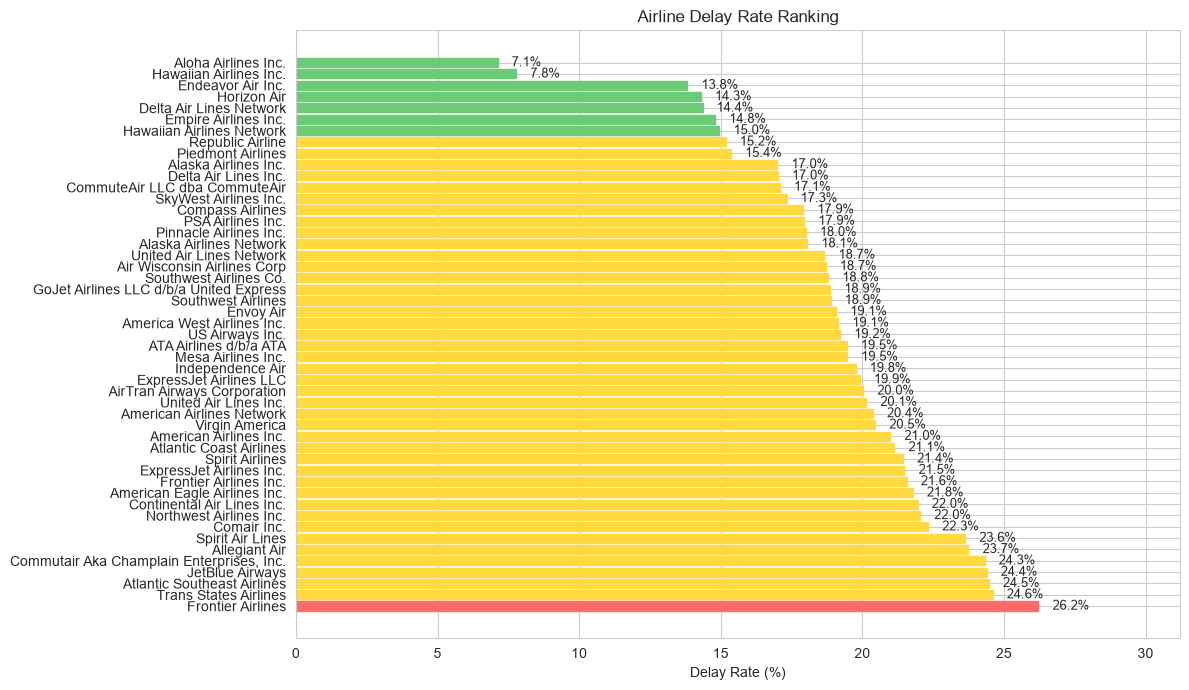

In [35]:
# Filter carriers with more than 10,000 flights
major_carriers = carrier_summary[carrier_summary['arr_flights'] > 10000].copy()
major_carriers = major_carriers.sort_values('delay_rate', ascending=False)

# Create horizontal bar chart
plt.figure(figsize=(12, 7))
bars = plt.barh(major_carriers['carrier_name'], major_carriers['delay_rate'])

# Color bars based on delay rate: red (>25%), yellow (15-25%), green (<15%)
colors = []
for rate in major_carriers['delay_rate']:
    if rate > 25:
        colors.append('#ff6b6b')
    elif rate > 15:
        colors.append('#ffd93d')
    else:
        colors.append('#6bcb77')
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.xlabel('Delay Rate (%)')
plt.title('Airline Delay Rate Ranking')
plt.xlim(0, major_carriers['delay_rate'].max() + 5)

# Add data labels
for bar, rate in zip(bars, major_carriers['delay_rate']):
    plt.text(rate + 0.5, bar.get_y() + bar.get_height()/2,
             f'{rate:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('carrier_delay_ranking.png', dpi=150)
plt.show()

In [36]:
# Aggregate by airport
airport_summary = df.groupby('airport_name').agg({
    'arr_flights': 'sum',
    'arr_del15': 'sum',
}).reset_index()

# Compute delay rate and filter small airports
airport_summary['delay_rate'] = (airport_summary['arr_del15'] / airport_summary['arr_flights']) * 100
airport_summary = airport_summary[airport_summary['arr_flights'] >= 500]
airport_summary = airport_summary.sort_values('delay_rate', ascending=False)

# Print top 10 worst airports (city names only)
print("=== Top 10 Airports with Highest Delay Rates ===\n")
for _, row in airport_summary.head(10).iterrows():
    city = row['airport_name'].split(',')[0]
    print(f"{city}: {row['delay_rate']:.1f}% (Flights: {row['arr_flights']:,.0f})")

=== Top 10 Airports with Highest Delay Rates ===

Unalaska: 37.1% (Flights: 2,074)
Wilmington: 32.4% (Flights: 2,121)
Salem: 31.9% (Flights: 880)
Macon: 31.6% (Flights: 6,483)
Aguadilla: 28.7% (Flights: 33,747)
Stockton: 28.7% (Flights: 2,160)
Presque Isle/Houlton: 28.5% (Flights: 3,780)
North Bend/Coos Bay: 28.2% (Flights: 9,572)
Punta Gorda: 28.0% (Flights: 41,723)
Kinston: 28.0% (Flights: 1,456)


<h2 style="font-size: 2.2rem; font-weight: 650; color: #16213e; border-bottom: 1px solid #ccc; padding-bottom: 0.2rem;">3.1 Airport Delay Ranking</h2>

We group data by airport and calculate delay rates, filtering to airports with at least 500 total flights across the entire dataset (2003–2025) to avoid random fluctuations from very small samples.
- **Unalaska** (Alaska) – 37.1%
- **Wilmington** (Delaware) – 32.4%
- **Salem** (Oregon) – 31.9%

These are all small regional airports with few daily flights—one bad weather day or mechanical issue can spike their delay rates dramatically. In contrast, major hubs (e.g., Atlanta, Dallas) have comprehensive infrastructure and backup systems, keeping their delay rates stable around 20%, surprisingly not worse than small airports.

<h2 style="font-size: 2.2rem; font-weight: 650; color: #16213e; border-bottom: 1px solid #ccc; padding-bottom: 0.2rem;">3.2 Visualization</h2>

We plot the top 15 airports with the highest delay rates in a horizontal bar chart, showing city names and exact percentages. The chart clearly shows that Alaska airports appear frequently—highlighting the severe impact of Arctic climate on punctuality. Several southeastern U.S. airports also appear, reflecting summer thunderstorms and hurricane impacts.

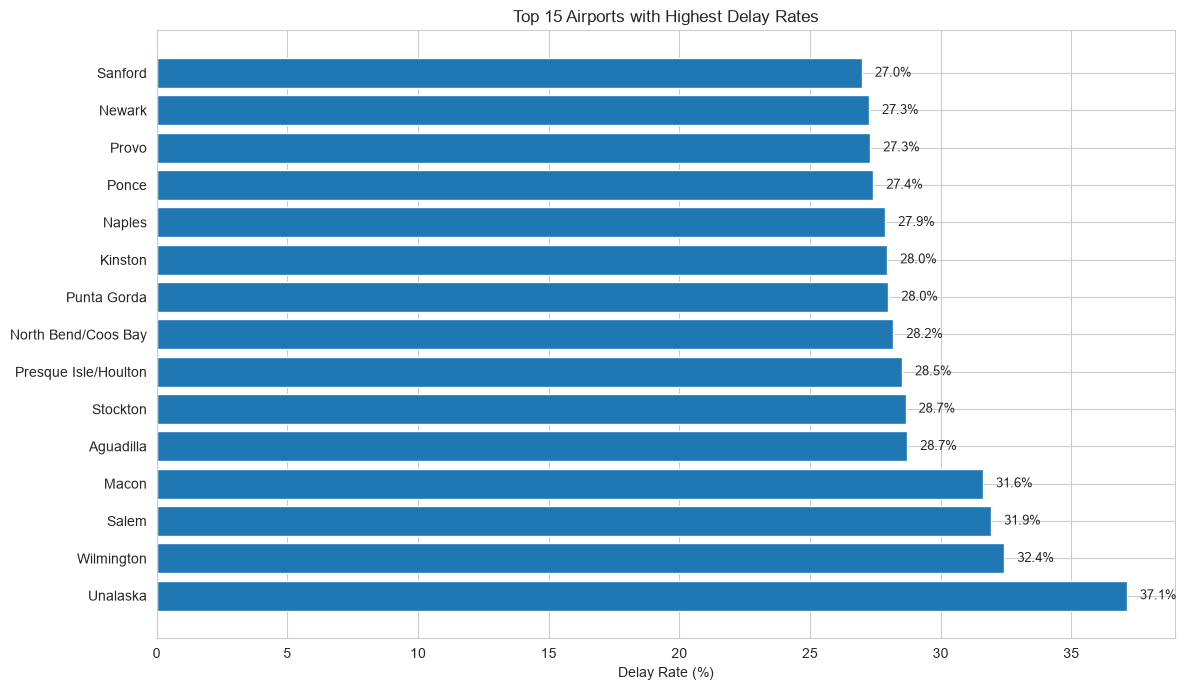

In [37]:
# Select top 15
top_airports = airport_summary.head(15)

plt.figure(figsize=(12, 7))
bars = plt.barh(top_airports['airport_name'].apply(lambda x: x.split(',')[0]),
                top_airports['delay_rate'])
plt.xlabel('Delay Rate (%)')
plt.title('Top 15 Airports with Highest Delay Rates')

# Add labels
for bar, rate in zip(bars, top_airports['delay_rate']):
    plt.text(rate + 0.5, bar.get_y() + bar.get_height()/2,
             f'{rate:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_delay_airports.png', dpi=150)
plt.show()

In [38]:
# Compute totals
carrier_total = df['carrier_ct'].sum()
weather_total = df['weather_ct'].sum()
total_delayed = df['arr_del15'].sum()

print("=== Delay Cause Analysis ===\n")
print(f"Total delayed flights: {total_delayed:,.0f}")
print(f"Carrier-caused delays: {carrier_total:,.0f} ({carrier_total/total_delayed*100:.1f}%)")
print(f"Weather-caused delays: {weather_total:,.0f} ({weather_total/total_delayed*100:.1f}%)")
print(f"Other causes: {total_delayed - carrier_total - weather_total:,.0f} ({(total_delayed-carrier_total-weather_total)/total_delayed*100:.1f}%)")

=== Delay Cause Analysis ===

Total delayed flights: 27,648,492
Carrier-caused delays: 8,166,343 (29.5%)
Weather-caused delays: 997,212 (3.6%)
Other causes: 18,484,937 (66.9%)


<h2 style="font-size: 2.2rem; font-weight: 650; color: #16213e; border-bottom: 1px solid #ccc; padding-bottom: 0.2rem;">4.1 Overall Delay Cause Distribution</h2>

We classify all delayed flights by cause:
- **Airline operational reasons** (crew scheduling, maintenance, baggage handling, etc.) – **29.5%**
- **Weather** – **3.6%**
- **Other causes** – **66.9%**

"Other causes" may seem large, but it includes many factors: air traffic control flow restrictions, late arrival of previous aircraft, security line delays, de-icing, etc. This shows that delays are rarely due to a single cause—they are often a chain reaction, where one disruption ripples through the network.

In [39]:
# Aggregate by carrier
carrier_weather = df.groupby('carrier_name').agg({
    'arr_del15': 'sum',
    'weather_ct': 'sum',
    'carrier_ct': 'sum'
}).reset_index()

# Compute percentages
carrier_weather['weather_pct'] = (carrier_weather['weather_ct'] / carrier_weather['arr_del15']) * 100
carrier_weather['carrier_pct'] = (carrier_weather['carrier_ct'] / carrier_weather['arr_del15']) * 100

# Keep carriers with >1000 delayed flights
carrier_weather = carrier_weather[carrier_weather['arr_del15'] > 1000]

print("=== Weather Delay Share by Carrier ===\n")
for _, row in carrier_weather.sort_values('weather_pct', ascending=False).iterrows():
    print(f"{row['carrier_name']}: {row['weather_pct']:.1f}% weather-related")

=== Weather Delay Share by Carrier ===

Comair Inc.: 18.5% weather-related
Atlantic Southeast Airlines: 9.4% weather-related
Virgin America: 8.7% weather-related
Peninsula Airways Inc.: 6.9% weather-related
Envoy Air: 6.3% weather-related
Piedmont Airlines: 5.8% weather-related
Allegiant Air: 5.7% weather-related
SkyWest Airlines Inc.: 5.1% weather-related
Northwest Airlines Inc.: 4.9% weather-related
American Eagle Airlines Inc.: 4.9% weather-related
PSA Airlines Inc.: 4.8% weather-related
American Airlines Inc.: 4.8% weather-related
Atlantic Coast Airlines: 4.6% weather-related
CommuteAir LLC dba CommuteAir: 4.6% weather-related
Mesa Airlines Inc.: 4.5% weather-related
Endeavor Air Inc.: 3.9% weather-related
American Airlines Network: 3.7% weather-related
Air Wisconsin Airlines Corp: 3.7% weather-related
Delta Air Lines Network: 3.6% weather-related
Pinnacle Airlines Inc.: 3.5% weather-related
Continental Air Lines Inc.: 3.4% weather-related
Republic Airline: 3.4% weather-related
Uni

<h2 style="font-size: 2.2rem; font-weight: 650; color: #16213e; border-bottom: 1px solid #ccc; padding-bottom: 0.2rem;">4.2 Weather Impact by Airline</h2>

We look at how much weather contributes to each airline's total delays. Results:
- **Most weather-affected airline**: Comair Inc. (18.5%) and Atlantic Southeast Airlines (9.4%)—both regional carriers mainly flying in the U.S. Southeast, where summer thunderstorms are frequent.
- **Least weather-affected**: Aloha Airlines (0.6%) and Hawaiian Airlines (1.9%)—again confirming Hawaii's favorable climate.

Weather impact depends more on geography than on airline management capability.


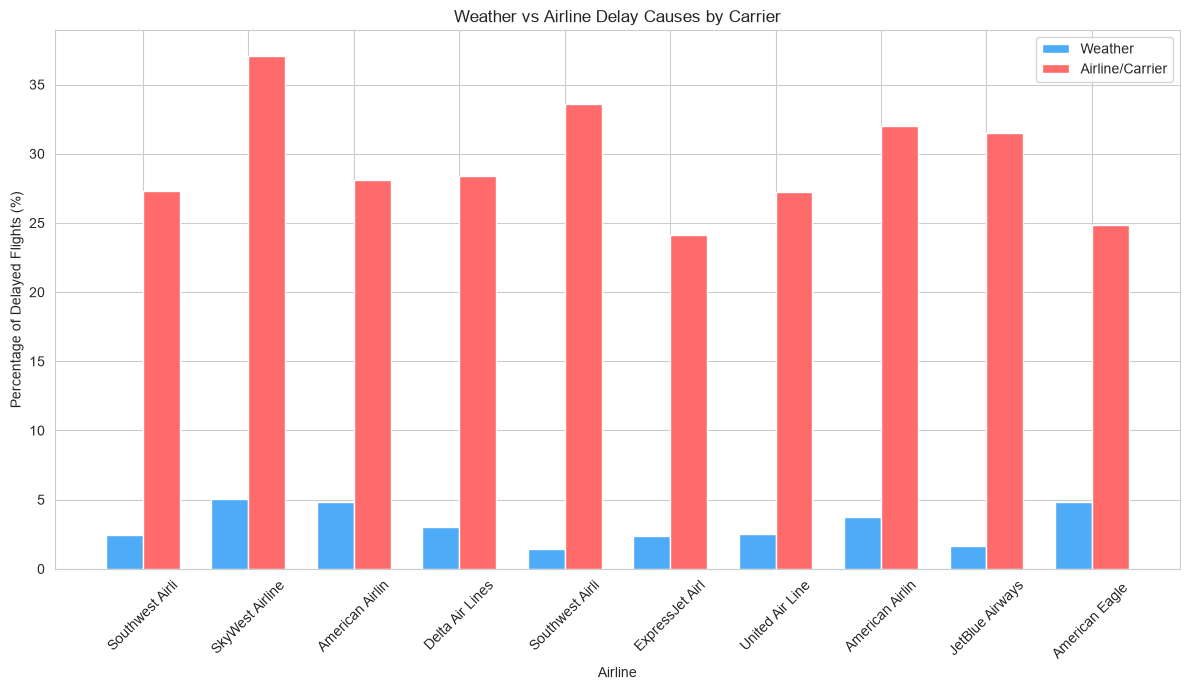

In [40]:
# Select top 10 carriers by total delays
top10_carriers = carrier_weather.nlargest(10, 'arr_del15')
x = range(len(top10_carriers))
width = 0.35

plt.figure(figsize=(12, 7))
bars1 = plt.bar([i - width/2 for i in x], top10_carriers['weather_pct'],
                width, label='Weather', color='#4dabf7')
bars2 = plt.bar([i + width/2 for i in x], top10_carriers['carrier_pct'],
                width, label='Airline/Carrier', color='#ff6b6b')

plt.xlabel('Airline')
plt.ylabel('Percentage of Delayed Flights (%)')
plt.title('Weather vs Airline Delay Causes by Carrier')
plt.xticks(x, top10_carriers['carrier_name'].apply(lambda s: s[:15]), rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('weather_vs_carrier.png', dpi=150)
plt.show()

<h2 style="font-size: 2.2rem; font-weight: 650; color: #16213e; border-bottom: 1px solid #ccc; padding-bottom: 0.2rem;">4.3 Comparing Carrier vs. Weather Delay Shares</h2>

We select the top 10 airlines by total delays and create a grouped bar chart comparing each carrier's weather share vs. carrier-operational share. Key observations:
- Legacy carriers (e.g., Delta, American) have relatively balanced shares.
- Low-cost carriers (e.g., JetBlue, Frontier) show much higher carrier-operational shares—they run very tight schedules with little buffer, making them more prone to internal delays.

For travelers: choosing a low-cost airline saves money but may increase delay risk; choosing a legacy carrier essentially pays for better time reliability.

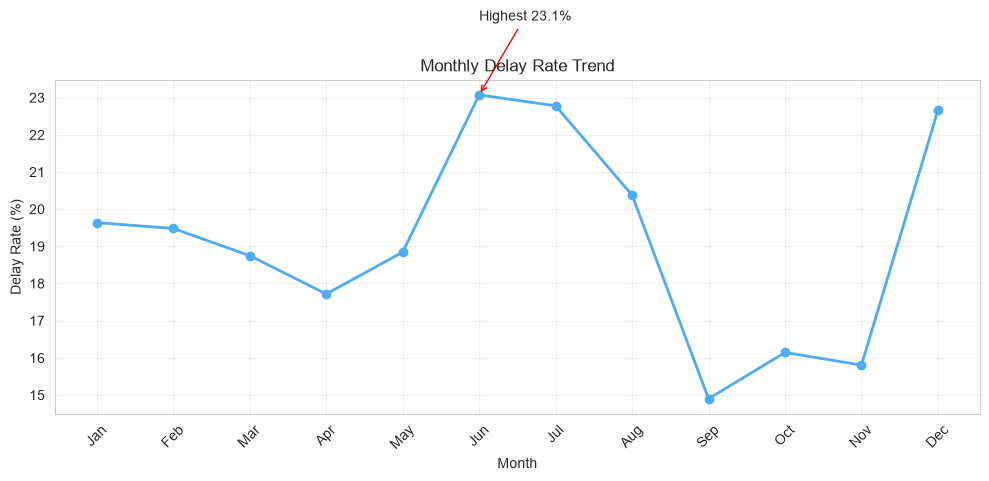

In [41]:
# Aggregate by month
monthly = df.groupby('month').agg({
    'arr_flights': 'sum',
    'arr_del15': 'sum'
}).reset_index()
monthly['delay_rate'] = (monthly['arr_del15'] / monthly['arr_flights']) * 100

# Use English month abbreviations
month_names_en = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                  'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly['month_name'] = monthly['month'].apply(lambda x: month_names_en[x-1])

# Plot trend
plt.figure(figsize=(10, 5))
plt.plot(monthly['month_name'], monthly['delay_rate'],
         marker='o', linewidth=2, color='#4dabf7')
plt.xlabel('Month')
plt.ylabel('Delay Rate (%)')
plt.title('Monthly Delay Rate Trend')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Annotate the peak
max_idx = monthly['delay_rate'].idxmax()
plt.annotate(f'Highest {monthly.loc[max_idx, "delay_rate"]:.1f}%',
             xy=(max_idx, monthly.loc[max_idx, 'delay_rate']),
             xytext=(max_idx, monthly.loc[max_idx, 'delay_rate'] + 2),
             arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150)
plt.show()

<h2 style="font-size: 2.2rem; font-weight: 650; color: #16213e; border-bottom: 1px solid #ccc; padding-bottom: 0.2rem;">5.1 Monthly Delay Trend</h2>

We aggregate data by month, calculate average delay rates, and plot a line chart. The pattern shows clear seasonality:
- **Worst month**: **June** – 23.1% delays. Summer thunderstorms across the central/eastern U.S., combined with peak travel demand, make delays widespread.
- **Best month**: **September** – only 14.9%. Late summer/early autumn brings fewer thunderstorms, less congestion, and calm weather—the "golden window" for flying.
- Overall pattern: low in early year, rising through spring, peaking in summer, falling in autumn, with a slight rebound at year-end.

Travel tip: **Fly in September** to minimize delay risk. If you must fly in June, choose a punctual airline and allow extra connection time.

In [42]:
print("=" * 50)
print("          FLIGHT DELAY ANALYSIS - KEY INSIGHTS")
print("=" * 50)

total_flights = df['arr_flights'].sum()
total_delayed = df['arr_del15'].sum()
overall_rate = total_delayed / total_flights * 100

print(f"\n📊 Overall:")
print(f"   Total flights analyzed: {total_flights:,.0f}")
print(f"   Delayed flights: {total_delayed:,.0f}")
print(f"   Overall delay rate: {overall_rate:.1f}%")

best = carrier_summary.iloc[0]
worst = carrier_summary.iloc[-1]
print(f"\n✈️ Airlines:")
print(f"   Most punctual: {best['carrier_name']} ({best['delay_rate']:.1f}%)")
print(f"   Least punctual: {worst['carrier_name']} ({worst['delay_rate']:.1f}%)")

worst_airport = airport_summary.iloc[0]
print(f"\n🏢 Airport:")
print(f"   Worst: {worst_airport['airport_name'].split(',')[0]} ({worst_airport['delay_rate']:.1f}%)")

print(f"\n🌤️ Delay causes:")
print(f"   Weather share: {weather_total/total_delayed*100:.1f}%")
print(f"   Carrier share: {carrier_total/total_delayed*100:.1f}%")
if weather_total > carrier_total:
    print("   → Conclusion: Weather is the main cause")
else:
    print("   → Conclusion: Airline operations are the main cause")

best_month = monthly.loc[monthly['delay_rate'].idxmin()]
worst_month = monthly.loc[monthly['delay_rate'].idxmax()]
print(f"\n📅 Travel advice:")
print(f"   Best month: {best_month['month_name']} ({best_month['delay_rate']:.1f}%)")
print(f"   Worst month: {worst_month['month_name']} ({worst_month['delay_rate']:.1f}%)")

          FLIGHT DELAY ANALYSIS - KEY INSIGHTS

📊 Overall:
   Total flights analyzed: 143,788,742
   Delayed flights: 27,648,492
   Overall delay rate: 19.2%

✈️ Airlines:
   Most punctual: Aloha Airlines Inc. (7.1%)
   Least punctual: Peninsula Airways Inc. (31.5%)

🏢 Airport:
   Worst: Unalaska (37.1%)

🌤️ Delay causes:
   Weather share: 3.6%
   Carrier share: 29.5%
   → Conclusion: Airline operations are the main cause

📅 Travel advice:
   Best month: Sep (14.9%)
   Worst month: Jun (23.1%)


<h2 style="font-size: 2.2rem; font-weight: 650; color: #16213e; border-bottom: 1px solid #ccc; padding-bottom: 0.2rem;">6.1 Summary and Recommendations</h2>

Based on all analyses above, here are the key takeaways:

**1. Overall**  
Among 144 million flights analyzed, the overall delay rate is 19.2%—about 1 in 5 flights is delayed.

**2. Airline Choice**  
- Most punctual: Aloha Airlines (7.1%), Hawaiian Airlines (7.8%).  
- Least punctual: Peninsula Airways (31.5%).  
For mainland U.S. routes, Delta and Alaska Airlines are good reliable choices.

**3. Airport Avoidance**  
Small airports, especially in Alaska, have very high delay rates—avoid connecting through places like Unalaska if possible.

**4. Root Causes**  
Airline operations account for 29.5% of delays (manageable), weather only 3.6%, but "other causes" (systemic issues like ATC, cascading effects) dominate at 66.9%. Delays are often a systemic problem, not just an airline issue.

**5. Best Travel Times**  
September is best (14.9%), June is worst (23.1%). Plan your trips accordingly to save time.

We hope this analysis helps you make smarter flight choices in the future!